# Trend Analysis and Revenue Forecasting

In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from analytics.db import run_query

In [4]:
def classify_trend(slope):

    if slope > 0:
        return "UP"

    elif slope < 0:
        return "DOWN"

    else:
        return "FLAT"

In [5]:
fact_profit_loss = run_query("""
SELECT *
FROM fact_profit_loss
""")

trend_df = fact_profit_loss[
    fact_profit_loss["fiscal_year"].notnull()
].copy()

trend_df["fiscal_year"] = trend_df[
    "fiscal_year"
].astype(int)

trend_df = trend_df.sort_values(
    by=["company_id", "fiscal_year"]
)

In [6]:
trend_results = []
companies = trend_df["company_id"].unique()

for company in companies:

    company_df = trend_df[
        trend_df["company_id"] == company
    ]

    if len(company_df) < 5:
        continue

    recent_df = company_df.tail(5)

    X = recent_df["fiscal_year"].values.reshape(-1,1)

    y = recent_df["sales"].values

    model = LinearRegression()

    model.fit(X, y)

    slope = model.coef_[0]

    trend_results.append({
        "company_id": company,
        "trend_slope": slope,
        "trend_label": classify_trend(slope)
    })

In [7]:
trend_results_df = pd.DataFrame(
    trend_results
)

trend_results_df.head()

,company_id,trend_slope,trend_label
0,ABB,455.100000,UP
1,ADANIENSOL,1374.900000,UP
2,ADANIENT,19403.900000,UP
3,ADANIGREEN,1799.400000,UP
4,ADANIPORTS,4947.857143,UP


In [8]:
trend_results_df["trend_label"].value_counts()

trend_label
UP      98
DOWN     1
Name: count, dtype: int64

In [9]:
forecast_results = []

for company in companies:

    company_df = trend_df[
        trend_df["company_id"] == company
    ]

    if len(company_df) < 5:
        continue

    recent_df = company_df.tail(5)

    sales_series = recent_df["sales"].values

    try:

        model = ExponentialSmoothing(
            sales_series,
            trend="add"
        )

        fitted_model = model.fit()

        forecast = fitted_model.forecast(1)[0]

        forecast_results.append({
            "company_id": company,
            "forecasted_sales": forecast
        })

    except:
        pass

In [10]:
forecast_df = pd.DataFrame(
    forecast_results
)

forecast_df.head()

,company_id,forecasted_sales
0,ABB,6268.098765
1,ADANIENSOL,19920.999953
2,ADANIENT,116043.128374
3,ADANIGREEN,10664.000063
4,ADANIPORTS,29961.834863


In [11]:
final_forecast_df = trend_results_df.merge(
    forecast_df,
    on="company_id",
    how="left"
)

final_forecast_df.head()

,company_id,trend_slope,trend_label,forecasted_sales
0,ABB,455.100000,UP,6268.098765
1,ADANIENSOL,1374.900000,UP,19920.999953
2,ADANIENT,19403.900000,UP,116043.128374
3,ADANIGREEN,1799.400000,UP,10664.000063
4,ADANIPORTS,4947.857143,UP,29961.834863


In [14]:
top_forecast = final_forecast_df.sort_values(
    by="forecasted_sales",
    ascending=False
).head(10)

top_forecast.head(10)

,company_id,trend_slope,trend_label,forecasted_sales
57,LICI,52956.0,UP,893100.281499
74,RELIANCE,101481.3,UP,872191.462798
49,IOC,106298.4,UP,784874.995676
68,ONGC,71777.8,UP,595353.739011
82,TATAMOTORS,44989.2,UP,529888.999486
76,SBIN,41140.4,UP,527532.999502
20,BPCL,57003.8,UP,455529.413942
38,HDFCBANK,36512.2,UP,396543.996918
84,TATASTEEL,26576.7,UP,270334.411469
59,LT,19868.4,UP,258884.999604


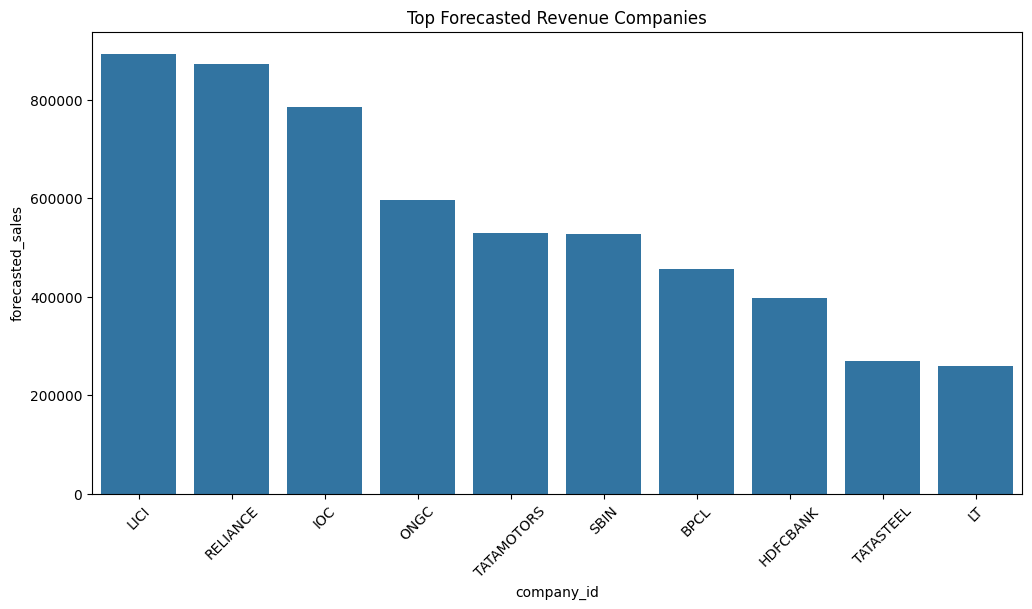

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_forecast,
    x="company_id",
    y="forecasted_sales"
)

plt.title("Top Forecasted Revenue Companies")

plt.xticks(rotation=45)

plt.show()

In [16]:
final_forecast_df.to_csv(
    "../exports/trend_forecast_results.csv",
    index=False
)